In [2]:
import numpy as np
import rebound
from scipy import signal
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [3]:
#helper functions
m_2 = 1.50137e-5
m_1 = 3.00274e-5
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

def get_freq_of_peri(alpha,n_jup,n_sat):
    laplace_coeff_1 = np.pi**(-1)*quad(lambda x: np.cos(x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]
    laplace_coeff_2 = np.pi**(-1)*quad(lambda x: np.cos(2*x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]

    A_11 = n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_1
    A_22 = n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_1
    A_12 = -n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_2
    A_21 = -n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_2

    sols = np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21])
    g_1 = sols[0]
    g_2 = sols[1]

    print(np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21]))
    return g_1,g_2  

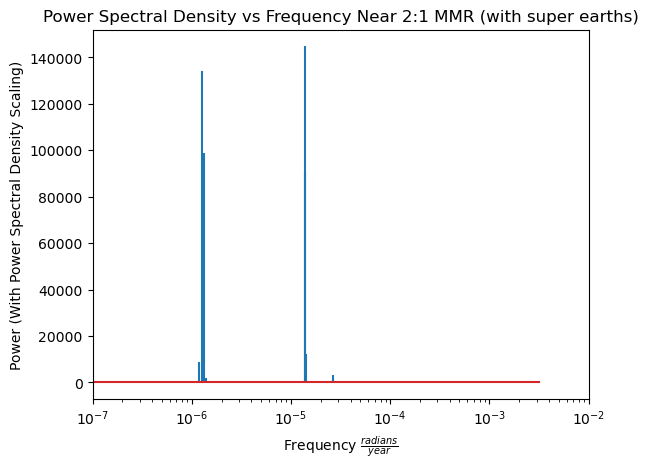

In [4]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 0.5/(2*np.pi)
sim.add(m=1, hash = "Sun")
sim.add(m=m_1,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="super_earth_1")
sim.add(m=m_2,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="super_earth_2")

alpha = 1/1.574

sim.move_to_com()

times = np.linspace(0,1e8,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))


for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e


f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency Near 2:1 MMR (with super earths)')
plt.show()

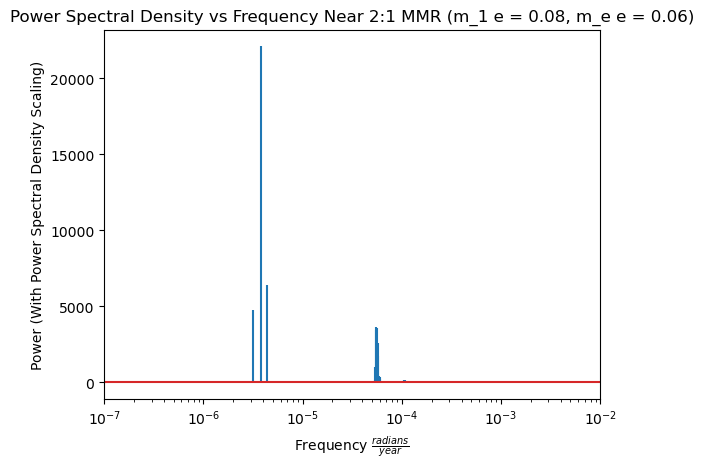

In [4]:
#based off of megno
m_1 = 3.00274e-5 
m_2 = 1.50137e-5

sim = rebound.Simulation()
sim.add(m=1, hash="Sun")
sim.add(m=m_1, a=5.6, e=0.08, inc=0, Omega=0, pomega=np.radians(13.983865))
sim.add(m=m_2, a=8.9, e=0.06, inc=0, Omega=0, pomega=np.radians(88.719425))

sim.integrator = "whfast"
sim.dt = 1e-1

sim.move_to_com()
times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))


for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency Near 2:1 MMR (m_1 e = 0.08, m_e e = 0.06)')
plt.show()

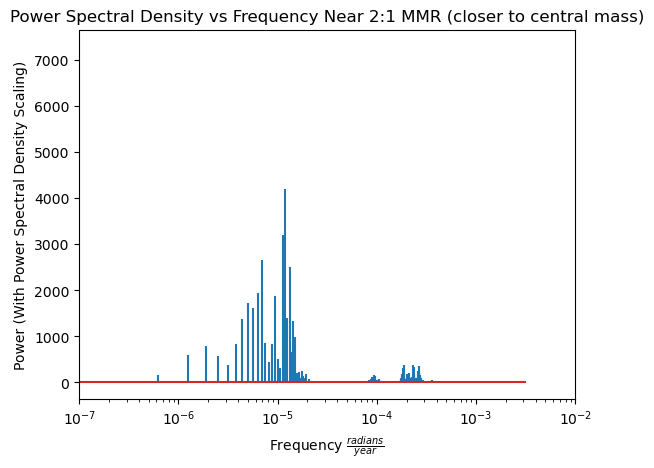

In [7]:
#estimates gained using megno chaos indicator
#megno value of 10.216254942434276
m_1 = 3.00274e-5 #10 earth masses
m_2 = 1.50137e-5 #5 earth masses

sim = rebound.Simulation()
sim.add(m=1, hash="Sun")
sim.add(m=m_1, a=2, e=0.08, inc=0, Omega=0, pomega=np.radians(13.983865))
sim.add(m=m_2, a=3.176, e=0.05, inc=0, Omega=0, pomega=np.radians(88.719425))

sim.integrator = "whfast"
sim.dt = 5e-2
times = np.linspace(0,1e7,int(1e4))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))


for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency Near 2:1 MMR (closer to central mass)')
plt.show()

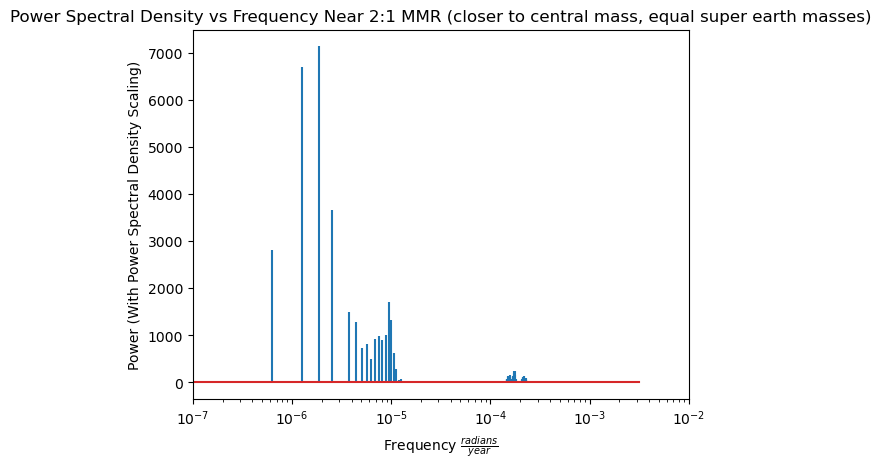

In [4]:
#estimates gained using megno chaos indicator
#megno value of 8.937912883844595

m_1 = 1.50137e-5 #5 earth masses
m_2 = 1.50137e-5

sim = rebound.Simulation()
sim.add(m=1, hash="Sun")
sim.add(m=m_1, a=2, e=0.08, inc=0, Omega=0, pomega=np.radians(13.983865))
sim.add(m=m_2, a=3.176, e=0.05, inc=0, Omega=0, pomega=np.radians(88.719425))

sim.integrator = "whfast"
sim.dt = 5e-2
times = np.linspace(0,1e7,int(1e4))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))


for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency Near 2:1 MMR (closer to central mass, equal super earth masses)')
plt.show()

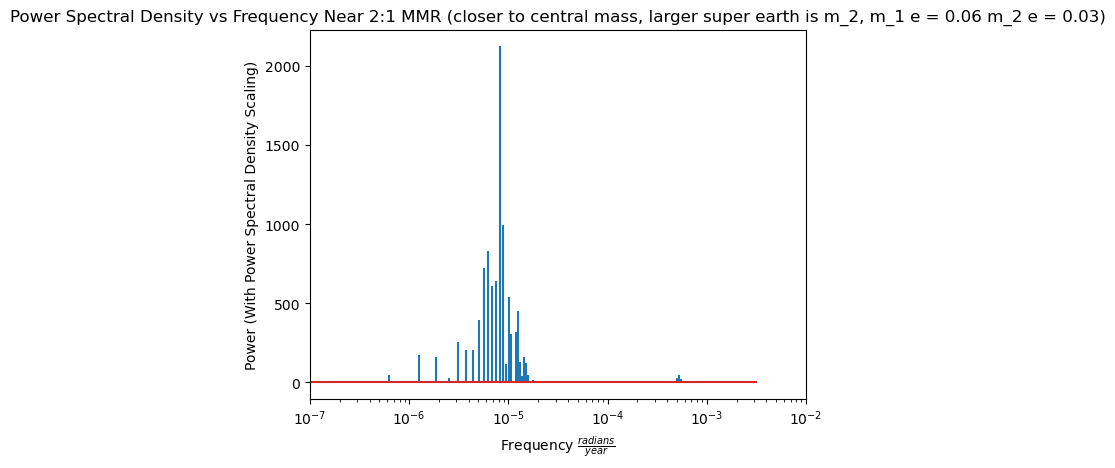

In [6]:
#megno value of 14.862732916995887

m_1 = 1.50137e-5 #5 earth masses
m_2 = 3.00274e-5 #10 earth masses

sim = rebound.Simulation()
sim.add(m=1, hash="Sun")
sim.add(m=m_1, a=2, e=0.06, inc=0, Omega=0, pomega=np.radians(13.983865))
sim.add(m=m_2, a=3.176, e=0.03, inc=0, Omega=0, pomega=np.radians(88.719425))

sim.integrator = "whfast"
sim.dt = 5e-2
times = np.linspace(0,1e7,int(1e4))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency Near 2:1 MMR (closer to central mass, larger super earth is m_2, m_1 e = 0.06 m_2 e = 0.03)')
plt.show()